In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [125]:
df_index=pd.read_csv('economic_index.csv')

In [126]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [127]:
###Drop unecessary columns

df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [128]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [129]:
### Check null values

df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

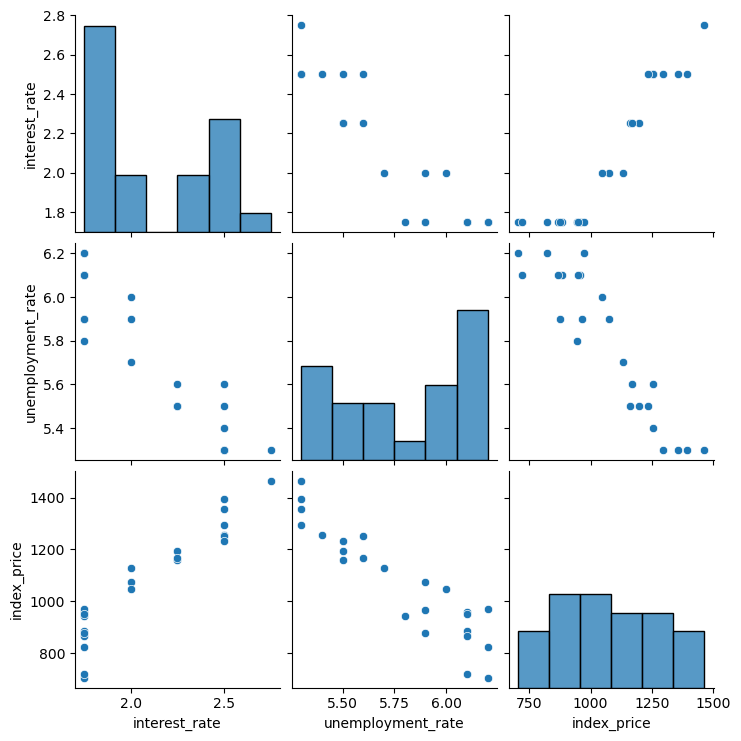

In [130]:
###Let's do some visualization

import seaborn as sns

sns.pairplot(df_index)

In [131]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

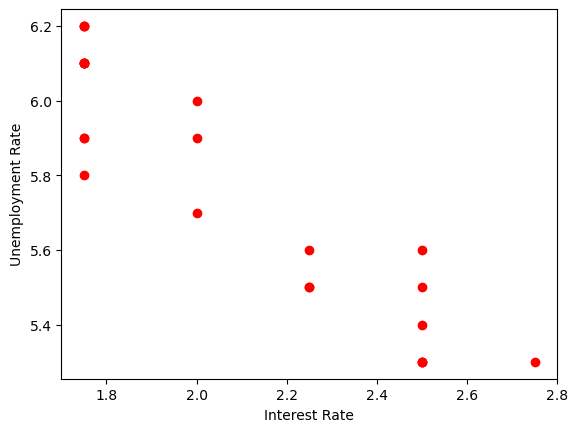

In [132]:
###Visualize the data points more closely

plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')

plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')


In [155]:
##Get my dependent and independent features

X=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [156]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [158]:
###Train test split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [159]:
import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='index_price'>

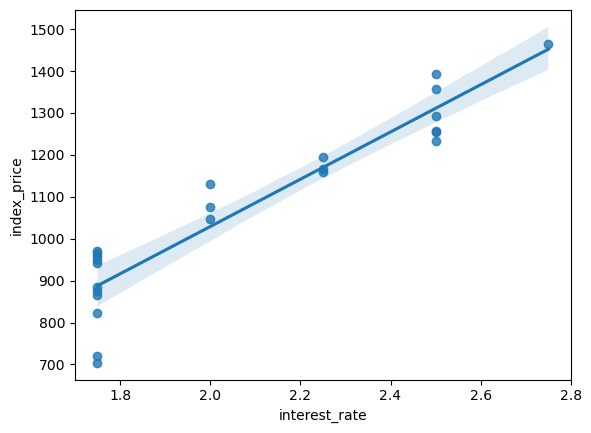

In [160]:
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

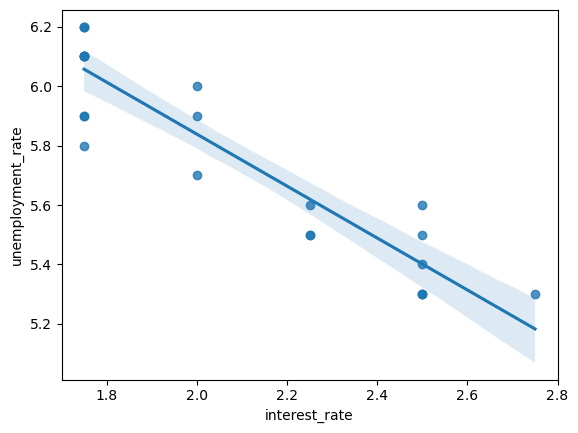

In [161]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])


<Axes: xlabel='unemployment_rate', ylabel='index_price'>

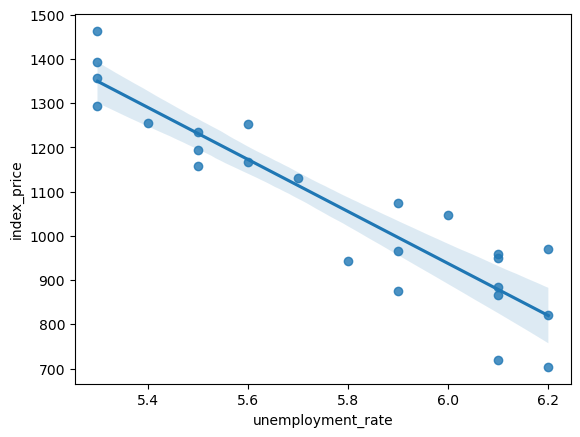

In [162]:
sns.regplot(x=df_index['unemployment_rate'],y=df_index['index_price'])


In [163]:
from sklearn.preprocessing import StandardScaler

In [164]:
scaler=StandardScaler()

In [165]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)


In [166]:
from sklearn.linear_model import LinearRegression

regression=LinearRegression()

In [168]:
regression.fit(X_train,y_train)

LinearRegression()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [169]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)


In [170]:
np.mean(validation_score)

np.float64(-5914.828180162395)

In [171]:
##Prediction

y_pred=regression.predict(X_test)

In [172]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


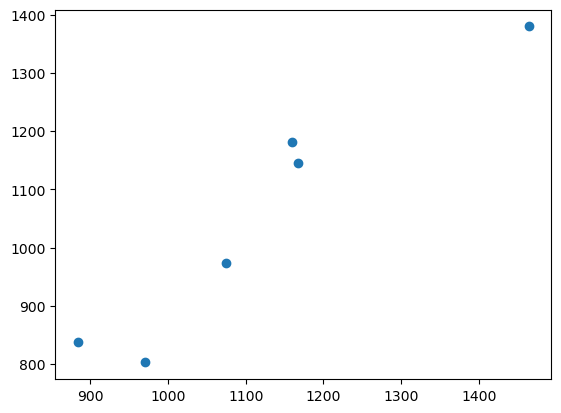

In [173]:
plt.scatter(y_test,y_pred)

In [174]:
residuals=y_test-y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


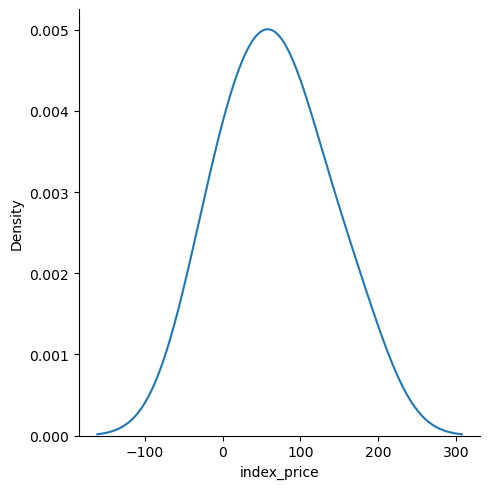

In [175]:
###plot residuals

sns.displot(residuals,kind='kde')

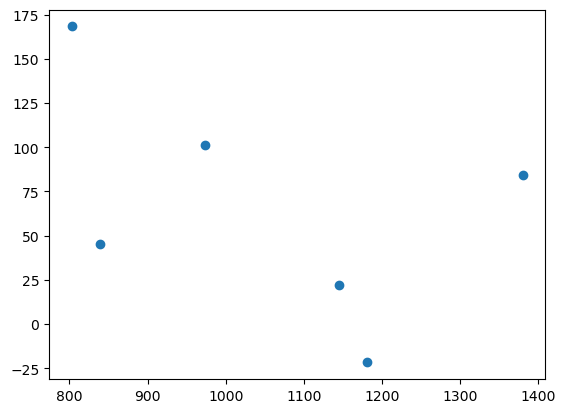

In [176]:
plt.scatter(y_pred,residuals)


In [177]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [178]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 13 Sep 2026   Prob (F-statistic):                       0.754
Time:                        12:59:05   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [179]:

print(regression.coef_)

[  88.27275507 -116.25716066]
